In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("used_cars.csv")


In [5]:

# Remove duplicates
df = df.drop_duplicates()

# Fill missing numeric values
df['Mileage(km)'] = df['Mileage(km)'].fillna(df['Mileage(km)'].median())
df['EngineSize(L)'] = df['EngineSize(L)'].fillna(df['EngineSize(L)'].median())

# Create car age
CURRENT_YEAR = 2026
if 'Year' in df.columns:
    df['CarAge'] = CURRENT_YEAR - df['Year']

print(df.columns)


Index(['Brand', 'Model', 'Year', 'CarAge', 'Condition', 'Mileage(km)',
       'EngineSize(L)', 'FuelType', 'Horsepower', 'Torque', 'Transmission',
       'DriveType', 'BodyType', 'Doors', 'Seats', 'Color', 'Interior',
       'Options', 'City', 'AccidentHistory', 'Insurance', 'RegistrationStatus',
       'FuelEfficiency(L/100km)', 'PricePerKm', 'Price'],
      dtype='str')


In [6]:
bins = [0, 20000, 60000, 100000, 200000, float('inf')]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['MileageBin'] = pd.cut(
    df['Mileage(km)'],
    bins=bins,
    labels=labels,
    include_lowest=True
)


In [7]:
categorical_cols = ['FuelType', 'Transmission', 'Brand', 'MileageBin']

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)


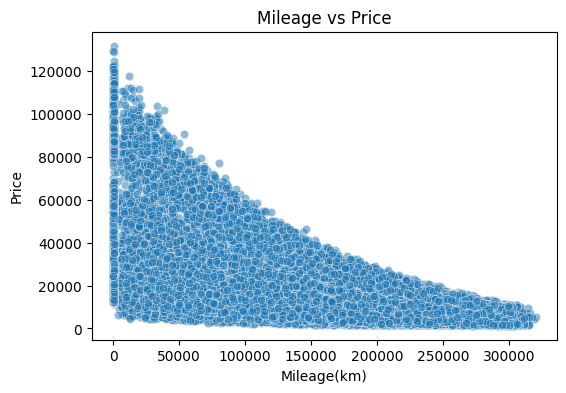

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Mileage(km)', y='Price', data=df, alpha=0.5)
plt.title("Mileage vs Price")
plt.show()


In [ ]:
# Ensure target is numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df.dropna(subset=['Price'])

# Use ONLY numeric columns (avoids 'Supra' error)
X = df.select_dtypes(include=[np.number]).drop(columns=['Price'])
y = df['Price']

# Fill remaining numeric NaNs
X = X.fillna(X.median())


In [11]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


Linear Regression MAE: 5810.060716344133
Linear Regression R2: 0.7163029261958396


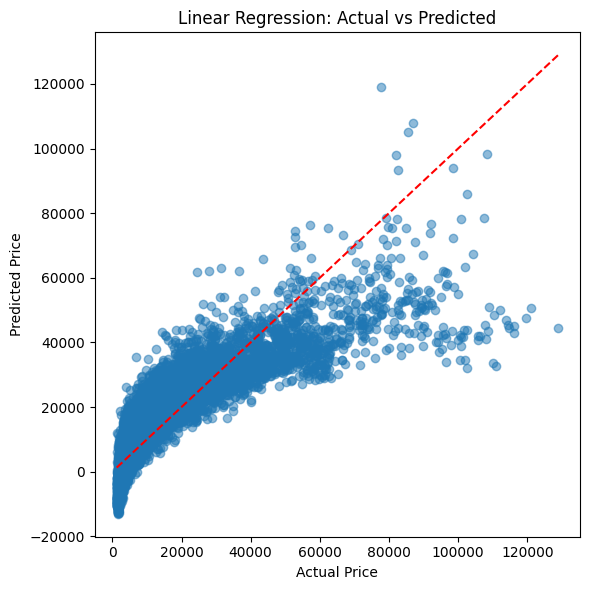

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression R2:", lr_r2)

plt.figure(figsize=(6,6))
plt.scatter(y_test, lr_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

Random Forest MAE: 640.9677935000001
Random Forest R2: 0.9890553682122966


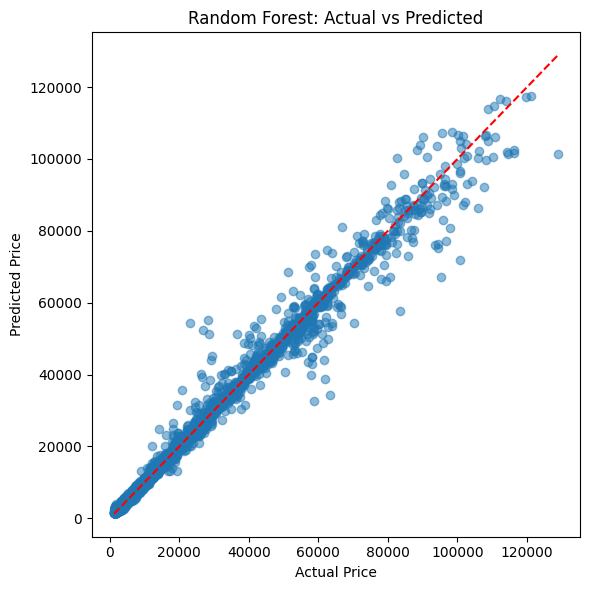

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)


plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.show()


In [18]:
df['PredictedPrice'] = rf_model.predict(X)
df['PriceDifference'] = df['Price'] - df['PredictedPrice']

df.to_csv("used_cars_with_predictions.csv", index=False)
print("✅ File exported for Power BI")


✅ File exported for Power BI
